<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B5%D0%B2%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%BC_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


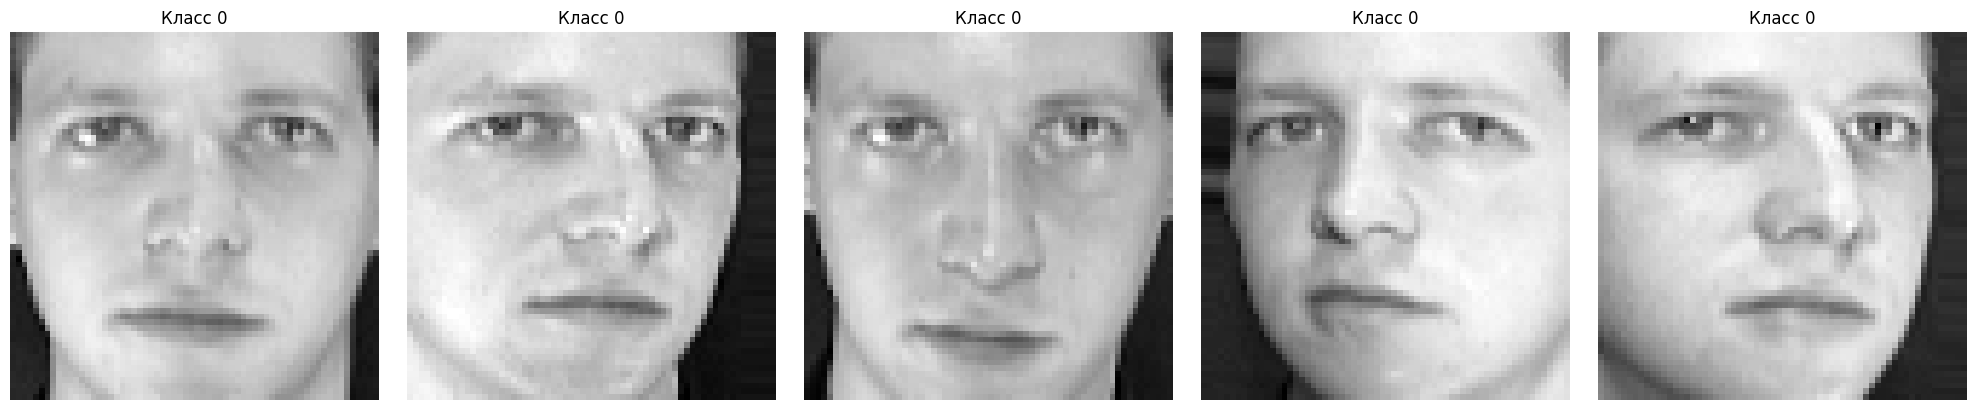

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [2]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

X = images.reshape(images.shape[0], -1)
X = X / 255 if X.max() > 1 else X
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

models = {
    'CatBoostClassifier': CatBoostClassifier(iterations=15, depth=3, learning_rate=0.2, loss_function='MultiClass', verbose=False, random_seed=42),
    'LGBMClassifier': LGBMClassifier(n_estimators=15, max_depth=3, learning_rate=0.2, random_state=42, verbose=-1),
    'XGBClassifier': XGBClassifier(n_estimators=15, max_depth=3, learning_rate=0.2, eval_metric='mlogloss', random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=15, max_depth=2, learning_rate=0.2, random_state=42)
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start
    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy, elapsed])

    print(name)
    print('Accuracy:', accuracy)
    print('Время обучения:', elapsed)
    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

results_df = pd.DataFrame(results, columns=['Модель', 'Accuracy', 'Время обучения'])
display(results_df.sort_values('Accuracy', ascending=False))


ModuleNotFoundError: No module named 'catboost'

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

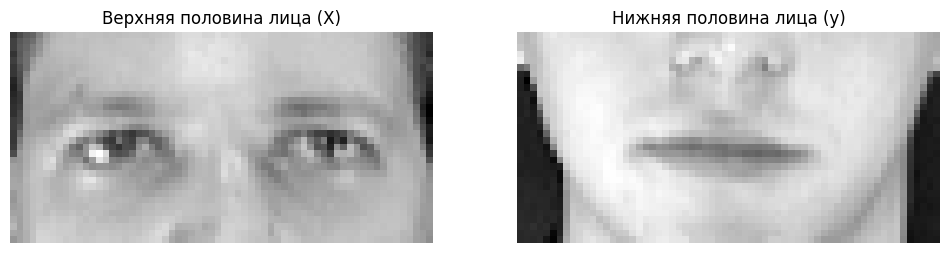

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [4]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

X = upper_half.reshape(n_samples, -1)
y = lower_half.reshape(n_samples, -1)
X = X / 255 if X.max() > 1 else X
y = y / 255 if y.max() > 1 else y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

pca_X = PCA(n_components=40, random_state=42)
pca_y = PCA(n_components=20, random_state=42)
X_train_pca = pca_X.fit_transform(X_train)
X_test_pca = pca_X.transform(X_test)
y_train_pca = pca_y.fit_transform(y_train)

models = {
    'CatBoostRegressor': CatBoostRegressor(iterations=15, depth=3, learning_rate=0.2, loss_function='MultiRMSE', verbose=False, random_seed=42),
    'LGBMRegressor': MultiOutputRegressor(LGBMRegressor(n_estimators=15, max_depth=3, learning_rate=0.2, random_state=42, verbose=-1)),
    'XGBRegressor': XGBRegressor(n_estimators=15, max_depth=3, learning_rate=0.2, objective='reg:squarederror', random_state=42),
    'GradientBoostingRegressor': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=15, max_depth=2, learning_rate=0.2, random_state=42))
}

results = []
predictions = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_pca, y_train_pca)
    y_pred_pca = model.predict(X_test_pca)
    y_pred = np.clip(pca_y.inverse_transform(y_pred_pca), 0, 1)
    elapsed = time.time() - start
    r2 = r2_score(y_test, y_pred)
    results.append([name, r2, elapsed])
    predictions[name] = y_pred

    print(name)
    print('R2:', r2)
    print('Время обучения:', elapsed)

results_df = pd.DataFrame(results, columns=['Модель', 'R2', 'Время обучения'])
display(results_df.sort_values('R2', ascending=False))

best_model = results_df.sort_values('R2', ascending=False).iloc[0]['Модель']
sample = 0
predicted_lower = predictions[best_model][sample].reshape(32, 64)
true_lower = y_test[sample].reshape(32, 64)
upper = X_test[sample].reshape(32, 64)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(upper, cmap='gray')
axes[0].set_title('Верхняя половина')
axes[1].imshow(true_lower, cmap='gray')
axes[1].set_title('Настоящая нижняя')
axes[2].imshow(predicted_lower, cmap='gray')
axes[2].set_title(f'Предсказанная нижняя: {best_model}')
for ax in axes:
    ax.axis('off')
plt.show()


ModuleNotFoundError: No module named 'catboost'

## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

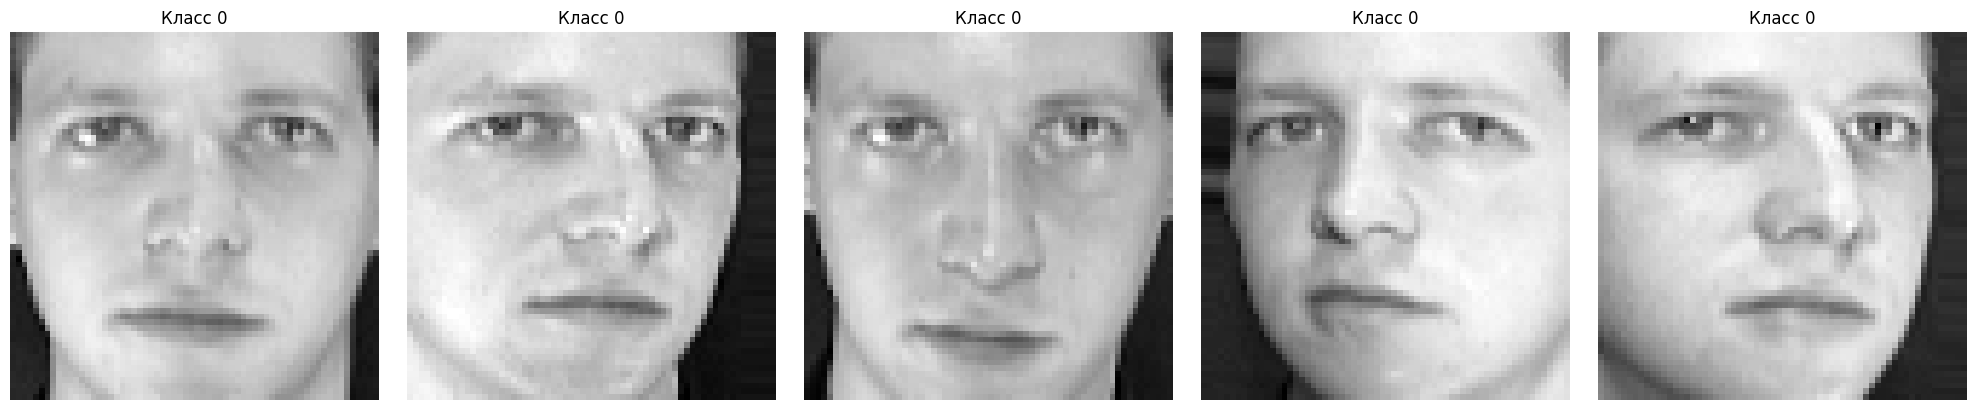

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

LogisticRegression
Accuracy: 0.98
Время обучения: 27.05754852294922
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16 

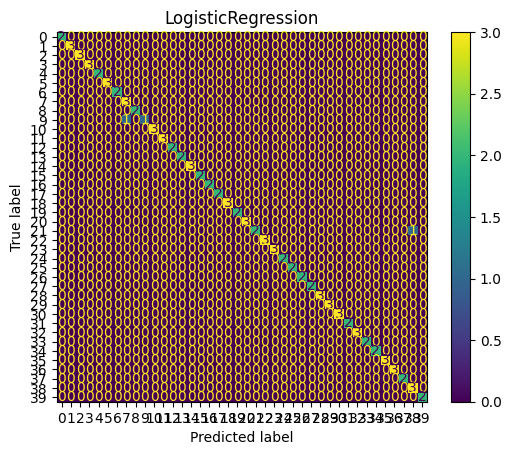

DecisionTreeClassifier
Accuracy: 0.25
Время обучения: 1.4137117862701416
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.50      0.50      0.50         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       1.00      0.50      0.67         2
          10       1.00      0.33      0.50         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         2
        

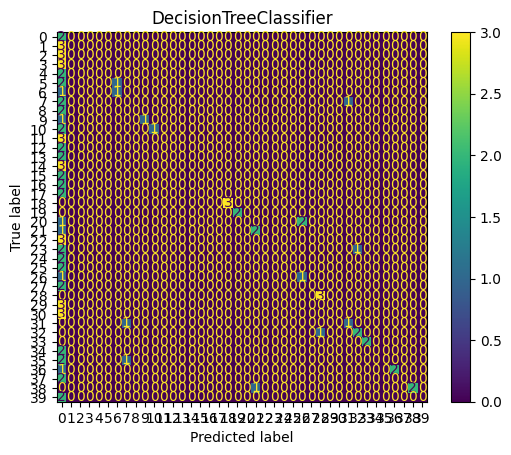

KNeighborsClassifier
Accuracy: 0.92
Время обучения: 0.027870893478393555
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       0.50      0.50      0.50         2
        

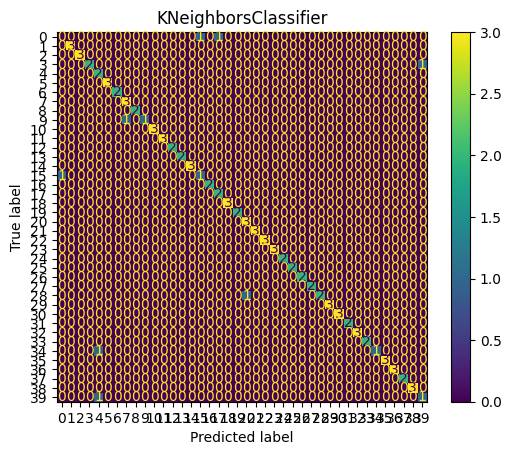

GaussianNB
Accuracy: 0.92
Время обучения: 0.07280659675598145
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.67      1.00      0.80         2
          13       1.00      0.50      0.67         2
          14       1.00      1.00      1.00         3
          15       0.50      1.00      0.67         2
          16       

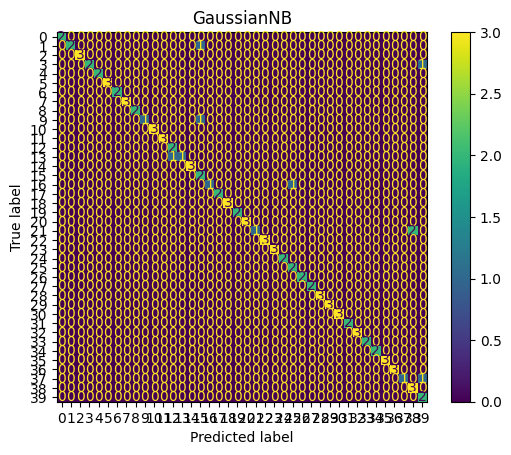

VotingClassifier
Accuracy: 0.96
Время обучения: 30.95389747619629
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      0.50      0.67         2
          16   

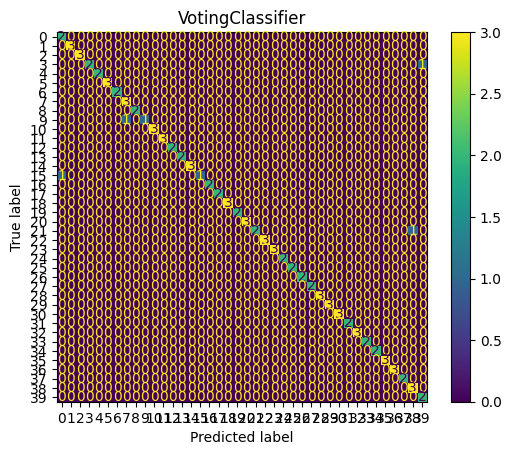

,Модель,Accuracy,Время обучения
0,LogisticRegression,0.98,27.057549
4,VotingClassifier,0.96,30.953897
2,KNeighborsClassifier,0.92,0.027871
3,GaussianNB,0.92,0.072807
1,DecisionTreeClassifier,0.25,1.413712


In [8]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

X = images.reshape(images.shape[0], -1)
X = X / 255 if X.max() > 1 else X
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=10, random_state=42),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=3),
    'GaussianNB': GaussianNB()
}

voting = VotingClassifier(
    estimators=[
        ('lr', models['LogisticRegression']),
        ('dt', models['DecisionTreeClassifier']),
        ('knn', models['KNeighborsClassifier']),
        ('nb', models['GaussianNB'])
    ],
    voting='hard'
)

models['VotingClassifier'] = voting
results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start
    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy, elapsed])

    print(name)
    print('Accuracy:', accuracy)
    print('Время обучения:', elapsed)
    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

results_df = pd.DataFrame(results, columns=['Модель', 'Accuracy', 'Время обучения'])
display(results_df.sort_values('Accuracy', ascending=False))


## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

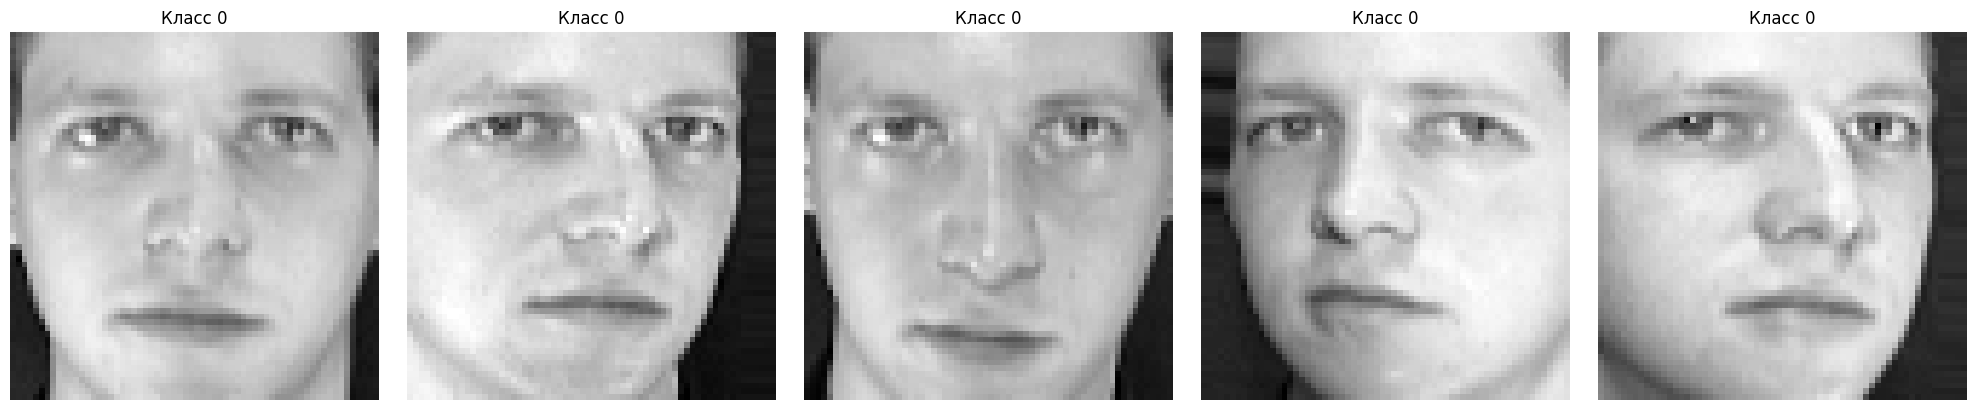

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


StackingClassifier
Accuracy: 0.97
Время обучения: 178.38696479797363
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16

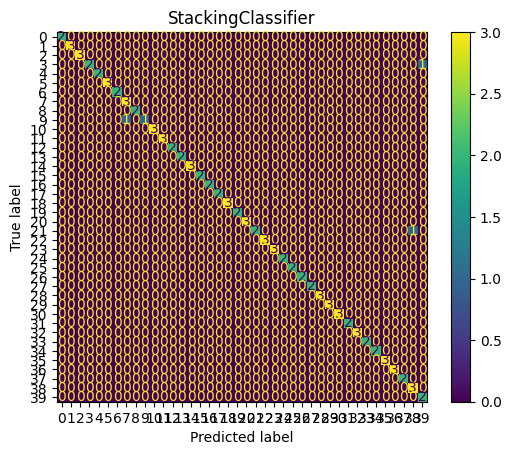

In [7]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier

X = images.reshape(images.shape[0], -1)
X = X / 255 if X.max() > 1 else X
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

base_models = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
    ('nb', GaussianNB())
]

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=500, random_state=42),
    cv=3
)

start = time.time()
stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)
elapsed = time.time() - start
accuracy = accuracy_score(y_test, y_pred)

print('StackingClassifier')
print('Accuracy:', accuracy)
print('Время обучения:', elapsed)
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('StackingClassifier')
plt.show()
